In [76]:
from sklearn.datasets import fetch_openml
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
import seaborn as sns

In [77]:
statlog_german_credit_data = fetch_openml(data_id=31, as_frame=True)
df = statlog_german_credit_data.data
label = statlog_german_credit_data.target


# Add the label to the dataframe
df["label"] = label

In [78]:
# Display basic information
print(df.columns)
print(df.head())

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'label'],
      dtype='object')
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2   

In [79]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,label
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [80]:
df.dtypes

checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
label                     category
dtype: object

In [81]:
for col in  df.columns:
    print(col + ":")
    print(df[col].unique())

checking_status:
['<0', '0<=X<200', 'no checking', '>=200']
Categories (4, object): ['0<=X<200', '<0', '>=200', 'no checking']
duration:
[ 6 48 12 42 24 36 30 15  9 10  7 60 18 45 11 27  8 54 20 14 33 21 16  4
 47 13 22 39 28  5 26 72 40]
credit_history:
['critical/other existing credit', 'existing paid', 'delayed previously', 'no credits/all paid', 'all paid']
Categories (5, object): ['all paid', 'critical/other existing credit', 'delayed previously', 'existing paid', 'no credits/all paid']
purpose:
['radio/tv', 'education', 'furniture/equipment', 'new car', 'used car', 'business', 'domestic appliance', 'repairs', 'other', 'retraining']
Categories (10, object): ['domestic appliance', 'new car', 'used car', 'business', ..., 'other', 'radio/tv', 'repairs', 'retraining']
credit_amount:
[ 1169  5951  2096  7882  4870  9055  2835  6948  3059  5234  1295  4308
  1567  1199  1403  1282  2424  8072 12579  3430  2134  2647  2241  1804
  2069  1374   426   409  2415  6836  1913  4020  5866  126

In [82]:
df.replace('other', np.nan, inplace=True)
df.dropna(inplace=True)

C:\Users\acer\AppData\Local\Temp\ipykernel_19792\3176561727.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df.replace('other', np.nan, inplace=True)


In [83]:
df = df.drop(columns=['personal_status', 'other_parties', 'num_dependents',"own_telephone", "savings_status", "foreign_worker", "num_dependents", "residence_since"])

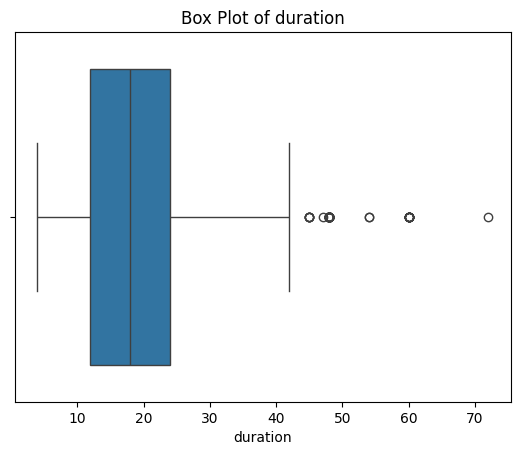

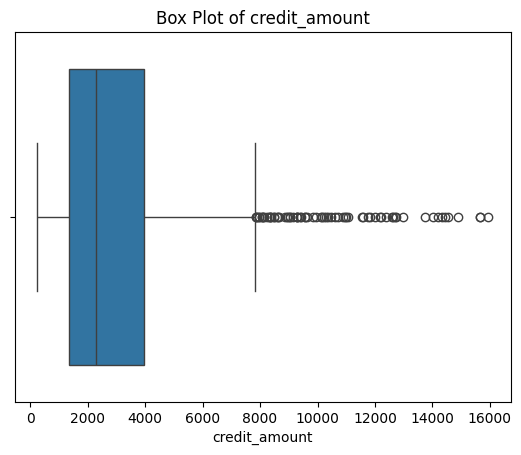

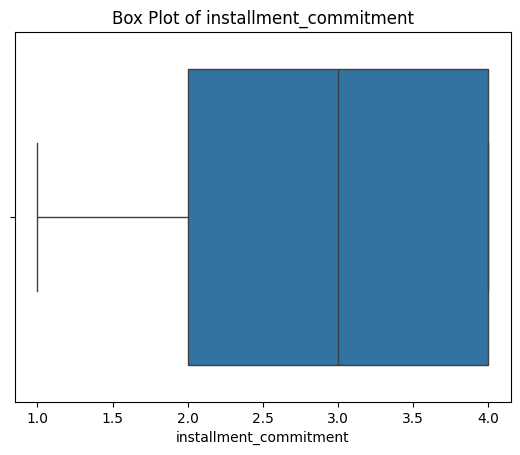

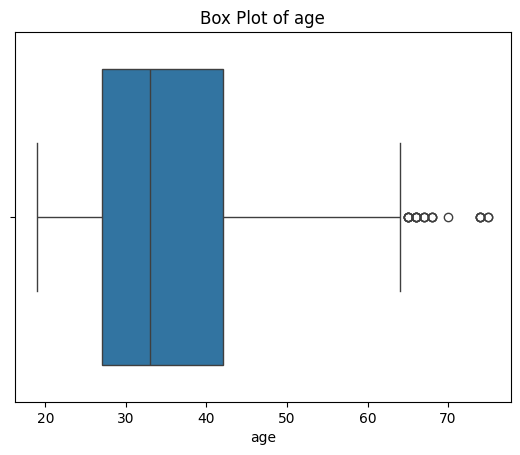

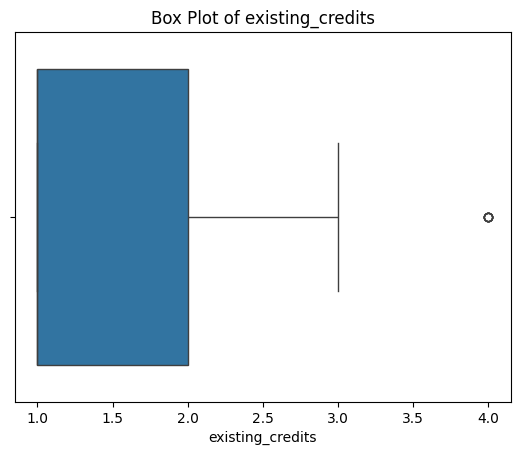

In [84]:
# Plot box plots for numerical features
numerical_features = df.select_dtypes(include=['number']).columns
for col in numerical_features:
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

In [85]:
# Remove outliers
df = df[df['duration'] <= 40]
df = df[df['age'] <= 65]
df = df[df['credit_amount'] <= 8000]

In [86]:
print(df.shape)
df.isnull().sum()

(854, 14)


checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
employment                0
installment_commitment    0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
label                     0
dtype: int64

In [87]:
# Separate features and label
y = df["label"]
x = df.drop(columns=['label'])

In [88]:
# Identify numerical and categorical features
numerical_features = x.select_dtypes(include=['number']).columns
categorical_features = list(set(x.columns) - set(numerical_features))

In [89]:
# One-hot encode categorical features
x = pd.get_dummies(x, columns=categorical_features, drop_first=True)

In [90]:
# Standardize numerical features
scaler = StandardScaler()
x[numerical_features] = scaler.fit_transform(x[numerical_features])

In [91]:
# Convert boolean columns to integers
boolean_columns = x.select_dtypes(include=['bool']).columns
x[boolean_columns] = x[boolean_columns].astype(int)

In [92]:
x.shape

(854, 34)

In [93]:
x.dtypes

duration                                         float64
credit_amount                                    float64
installment_commitment                           float64
age                                              float64
existing_credits                                 float64
employment_4<=X<7                                  int32
employment_<1                                      int32
employment_>=7                                     int32
employment_unemployed                              int32
job_unemp/unskilled non res                        int32
job_unskilled resident                             int32
job_skilled                                        int32
housing_own                                        int32
housing_rent                                       int32
property_magnitude_no known property               int32
property_magnitude_real estate                     int32
property_magnitude_car                             int32
other_payment_plans_none       

In [94]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 854 entries, 2 to 997
Data columns (total 34 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   duration                                       854 non-null    float64
 1   credit_amount                                  854 non-null    float64
 2   installment_commitment                         854 non-null    float64
 3   age                                            854 non-null    float64
 4   existing_credits                               854 non-null    float64
 5   employment_4<=X<7                              854 non-null    int32  
 6   employment_<1                                  854 non-null    int32  
 7   employment_>=7                                 854 non-null    int32  
 8   employment_unemployed                          854 non-null    int32  
 9   job_unemp/unskilled non res                    854 non-null

In [95]:
y = y.apply(lambda x: 1 if x == 'bad' else 0)
y = y.astype(int)
y

2      0
4      1
6      0
7      0
8      0
      ..
993    0
994    0
995    0
996    0
997    0
Name: label, Length: 854, dtype: int32

In [96]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=123)

print("Training feature set size:",X_train.shape)
print("Test feature set size:",X_test.shape)
print("Training variable set size:",y_train.shape)
print("Test variable set size:",y_test.shape)

Training feature set size: (597, 34)
Test feature set size: (257, 34)
Training variable set size: (597,)
Test variable set size: (257,)


In [97]:
# Build the model with regularization and dropout
model = Sequential([
    Dense(150, input_shape=(X_train.shape[1],), activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(100, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(25, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4995 - loss: 0.9550 - val_accuracy: 0.7121 - val_loss: 0.7940
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7281 - loss: 0.8055 - val_accuracy: 0.7121 - val_loss: 0.7730
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7251 - loss: 0.8118 - val_accuracy: 0.7121 - val_loss: 0.7573
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7532 - loss: 0.7373 - val_accuracy: 0.7121 - val_loss: 0.7410
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7299 - loss: 0.7413 - val_accuracy: 0.7121 - val_loss: 0.7272
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7319 - loss: 0.7337 - val_accuracy: 0.7121 - val_loss: 0.7147
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7400 - loss: 0.7029 - val_accuracy: 0.7121 - val_loss: 0.7058
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7641 - loss: 0.6570 - val_accuracy: 0.7121 - val_loss:

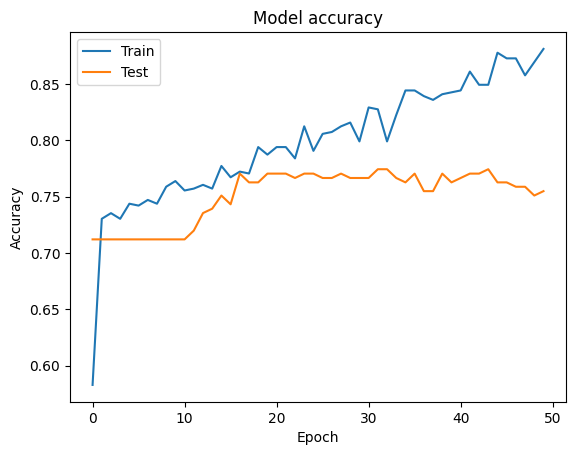

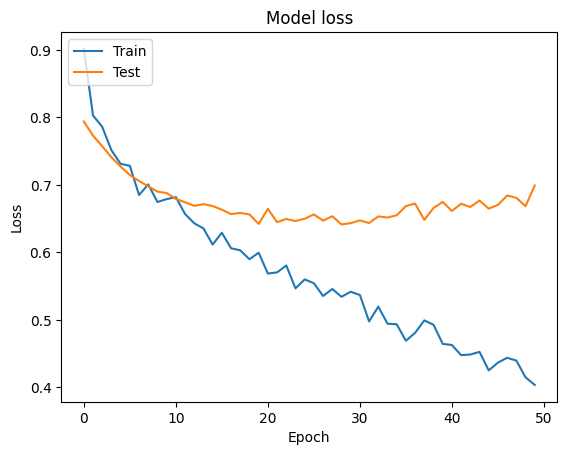

In [98]:
# Fit the model
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


In [99]:
# Predict and calculate training error
yhat_train = model.predict(X_train)
yhat_train = yhat_train.reshape(-1)
yhat_train = (yhat_train >= 0.5).astype(int)
train_error = np.mean(yhat_train != y_train)
print(f"Fraction of misclassified training data: {train_error}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fraction of misclassified training data: 0.09547738693467336


In [100]:
yhat_test = model.predict(X_test)
yhat_test = yhat_test.reshape(-1)
yhat_test = (yhat_test >= 0.5).astype(int)
test_error = np.mean(yhat_test != y_test)
print(f"Fraction of misclassified test data: {test_error}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step
Fraction of misclassified test data: 0.245136186770428
